# 1️⃣ Data Overview

## 🎯 Objetivo
Esse notebook realiza uma exploração inicial nos dados com o objetivo de entender:
- Estrutura dos dados
- Campos vazios
- Tipos das colunas
- Estatisticas iniciais

Essas analises serão essenciais para guiar as etapas de feature engineering e decisão dos modelos de predição.

### Origem dos dados


In [3]:
import sys
from pathlib import Path
import pandas as pd
ROOT_PATH = Path().resolve().parent
sys.path.append(str(ROOT_PATH))
from src.data.loader import carregar_planilhas
from src.data.integration import consolidar_datasets


- Carregar dados
- Limpar e organizar colunas
- Integrar todos os anos em um só dataset

In [151]:
arquivo = "../data/raw/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

datasets = carregar_planilhas(arquivo)

df = consolidar_datasets(datasets)

df.to_csv("../data/processed/dataset_consolidado.csv", index=False)

df.head()

,RA,Fase,Turma,Nome,AnoNascimento,Idade,Gênero,Ano ingresso,Instituição de ensino,Cg,...,INDE_2_anos_atras,Pedra,AnoReferencia,IPP,Destaque IPV.1,Avaliador5,Avaliador6,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1,7,A,Aluno-1,2003,19.0,Menina,2016,Escola Pública,753.0,...,NaN,Quartzo,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,2005,17.0,Menina,2017,Rede Decisão,469.0,...,NaN,Ametista,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,2005,17.0,Menina,2016,Rede Decisão,629.0,...,NaN,Ágata,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,2005,17.0,Menino,2017,Rede Decisão,731.0,...,NaN,Quartzo,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,2005,17.0,Menina,2016,Rede Decisão,344.0,...,NaN,Ametista,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [144]:
df.shape

(3030, 50)

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 50 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     3030 non-null   object 
 1   Fase                   3030 non-null   object 
 2   Turma                  3030 non-null   object 
 3   Nome                   3030 non-null   object 
 4   AnoNascimento          3030 non-null   Int64  
 5   Idade                  2631 non-null   float64
 6   Gênero                 3030 non-null   object 
 7   Ano ingresso           3030 non-null   int64  
 8   Instituição de ensino  3029 non-null   object 
 9   Cg                     860 non-null    float64
 10  Cf                     860 non-null    float64
 11  Ct                     860 non-null    float64
 12  Nº Av                  2954 non-null   float64
 13  Avaliador1             2827 non-null   object 
 14  Rec Av1                860 non-null    object 
 15  Aval

In [146]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RA,3030,1661,RA-1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fase,3030,88,ALFA,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Turma,3030,120,A,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nome,3030,1661,Aluno-1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AnoNascimento,3030.0,<NA>,<NA>,<NA>,2010.454455,3.314445,1996.0,2008.0,2011.0,2013.0,2017.0
Idade,2631.0,NaN,NaN,NaN,12.548081,3.283307,7.0,10.0,12.0,15.0,27.0
Gênero,3030,4,Feminino,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ano ingresso,3030.0,NaN,NaN,NaN,2021.563696,1.822171,2016.0,2021.0,2022.0,2023.0,2024.0
Instituição de ensino,3029,12,Pública,1722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cg,860.0,NaN,NaN,NaN,430.516279,248.432761,1.0,215.75,430.5,645.25,862.0


In [147]:
df.isnull().sum().sort_values(ascending=False).head(10)

Destaque IPV.1       3030
Avaliador6           3024
Avaliador5           2882
Rec Av4              2734
INDE_2_anos_atras    2558
Rec Av2              2170
Rec Av1              2170
Atingiu PV           2170
Indicado             2170
Destaque IPV         2170
dtype: int64

In [148]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False).head(15)

Destaque IPV.1       100.000000
Avaliador6            99.801980
Avaliador5            95.115512
Rec Av4               90.231023
INDE_2_anos_atras     84.422442
Rec Av2               71.617162
Rec Av1               71.617162
Atingiu PV            71.617162
Indicado              71.617162
Destaque IPV          71.617162
Rec Psicologia        71.617162
Rec Av3               71.617162
Destaque IEG          71.617162
Destaque IDA          71.617162
Ct                    71.617162
dtype: float64

In [149]:
df.nunique().sort_values().head(10)

Destaque IPV.1      0
Ativo/ Inativo.1    1
Avaliador6          1
Ativo/ Inativo      1
Destaque IPV        2
Destaque IDA        2
Destaque IEG        2
Atingiu PV          2
Indicado            2
AnoReferencia       3
dtype: int64

In [137]:
df['defasado_bin'] = (df['Defasagem'] < 0).astype(int)
df['defasado_bin'].value_counts(normalize=True)

defasado_bin
1    0.556766
0    0.443234
Name: proportion, dtype: float64

<Axes: xlabel='defasado_bin'>

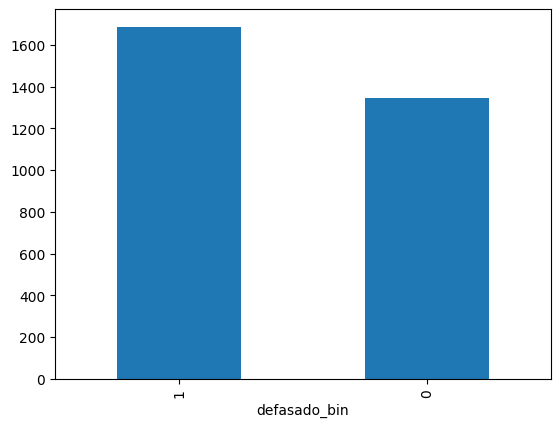

In [138]:
df['defasado_bin'].value_counts().plot(kind='bar')

# Definições
## Target escolhido
- defasado_bin

A variável Defasagem indica diferença entre fase ideal e fase real do aluno.
Para tornar o problema mais interpretável e aplicável na prática educacional, ela será transformada em variável binária (defasado_bin), indicando se o aluno está ou não defasado.

A distribuição da target é aproximadamente balanceada (55% vs 45%).

A métrica primária escolhida é ROC-AUC.

## Problema

Esse será um problema de classificação binária. 

## Objetivo

Realizar um modelo de previsão para auxiliar a equipe pedagógica identificando alunos em risco

### Observações

A variável Defasagem parece ser derivada de informações como Fase e FaseIdeal, o que será considerado na etapa de seleção de features para evitar vazamento de informação.

Será neceśsario remover colunas vazias ou com alta porcentagem de valores vazios, e colunas constantes ou duplicadas.
Como Idade possui valores ausentes e pode ser derivada de AnoNascimento, irei descartar a variável idade.
Essa parte de exclusão será feita em definitivo nos próximos passos, deixarei aqui para avaliação.

In [150]:
df = df.drop(columns=['Destaque IPV.1'])
df = df.drop(columns=['Ativo/ Inativo.1'])
df = df.drop(columns=['Avaliador6'])
df = df.drop(columns=['Avaliador5'])
df = df.drop(columns=['Ativo/ Inativo'])
df = df.drop(columns=['Idade'])